# Photon Injection Spectral Distortions

Generates `photon_injection_spectra.pdf` (Figure 6 in paper).

Three panels (x_inj = 0.1, 1.0, 5.0) showing PDE (solid) and GF (dashed) spectra at four injection redshifts.

In [ ]:
import os
from pathlib import Path

# Ensure cargo is on PATH
cargo_bin = Path.home() / '.cargo' / 'bin'
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(cargo_bin) + os.pathsep + os.environ.get('PATH', '')

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from spectroxide import (
    ALPHA_RHO, X_BALANCED, KAPPA_C, G2_PLANCK, G3_PLANCK,
    x_c_dc, x_c_br, x_c,
    photon_survival_probability,
    greens_function_photon, greens_function,
    mu_from_photon_injection,
    mu_shape, y_shape, temperature_shift_shape, g_bb, planck,
    j_bb_star, j_mu, j_y,
    delta_n_to_delta_I,
    apply_style,
)
from spectroxide.solver import solve

apply_style()

print(f"alpha_rho = G2/G3 = {ALPHA_RHO:.4f}")
print(f"x_0 (balanced) = 4/(3*alpha_rho) = {X_BALANCED:.3f}")
print(f"kappa_c = {KAPPA_C}")

# Conversion: x = 0.01761 * nu_GHz (for T_CMB = 2.726 K)
K_B = 1.380649e-23
H_PLANCK = 6.62607015e-34
T_CMB = 2.726
X_PER_GHZ = H_PLANCK * 1e9 / (K_B * T_CMB)
print(f"x per GHz = {X_PER_GHZ:.5f}")

def dn_to_intensity_1e20(x, dn):
    """Convert Δn(x) to ΔI in units of 10^{-20} W/m^2/Hz/sr."""
    nu_hz = x * K_B * T_CMB / H_PLANCK
    di_si = 2 * H_PLANCK * nu_hz**3 / (2.998e8)**2 * dn
    return di_si / 1e-20

def strip_gbb(x, dn):
    """Post-hoc number-conserving G_bb subtraction: make ∫x²Δn dx = 0."""
    gbb = g_bb(x)
    num = np.trapz(x**2 * dn, x)
    denom = np.trapz(x**2 * gbb, x)
    delta_t = num / denom
    return dn - delta_t * gbb, delta_t

def default_sigma_x(x_inj):
    """Choose sigma_x = 5% of x_inj (always proportional)."""
    return x_inj * 0.05

dn_over_n = 1e-5  # Default ΔN/N for all PDE runs

def run_pde_photon(x_inj, z_h, delta_n_over_n=1e-5, sigma_x=None,
                   z_end=50, n_points=None, timeout=600, **kwargs):
    """Run PDE solver for monochromatic photon injection.

    Uses production-quality defaults (4000 pts, production grid, dtau=1).
    Pass n_points to override grid resolution (e.g. 8000 for x_inj < 0.1).
    """
    if sigma_x is None:
        sigma_x = default_sigma_x(x_inj)
    solve_kwargs = dict(
        injection={
            'type': 'monochromatic_photon',
            'x_inj': x_inj,
            'delta_n_over_n': delta_n_over_n,
            'z_h': z_h,
            'sigma_x': sigma_x,
        },
        z_start=z_h + 7 * max(z_h * 0.04, 100),
        z_end=z_end,
        number_conserving=False,
        nc_z_min=0,
        timeout=timeout,
        n_points=8000,
    )
    if n_points is not None:
        solve_kwargs['n_points'] = n_points
    solve_kwargs.update(kwargs)
    result = solve(**solve_kwargs)
    return np.asarray(result.x), np.asarray(result.delta_n), result.mu, result.y

print("Quality defaults: PRODUCTION (4000 pts, production grid, dtau_max_photon_source=1.0)")


In [2]:
import time

# ---- Fig 2: mu vs x_i sweep at selected z_i values ----
# Cache for PDE spectral results, shared across Fig 5, 7, and later cells
pde_spectra = {}  # {(x_i, z_i): (x_grid, delta_n, mu, y)}

def get_pde_spectrum(x_inj, z_i, **kwargs):
    """Get PDE spectrum from cache, running solver if not cached."""
    key = (x_inj, z_i)
    if key not in pde_spectra:
        print(f"  Running PDE: x_i={x_inj}, z_i={z_i:.0e} ...", end='', flush=True)
        pde_spectra[key] = run_pde_photon(x_inj, z_i, **kwargs)
        print(f" mu={pde_spectra[key][2]:.3e}")
    return pde_spectra[key]

## Generate figure

  Running PDE: x_i=0.1, z_h=1e+04, n=4000 ...

TypeError: run_sweep() got an unexpected keyword argument 'injection'

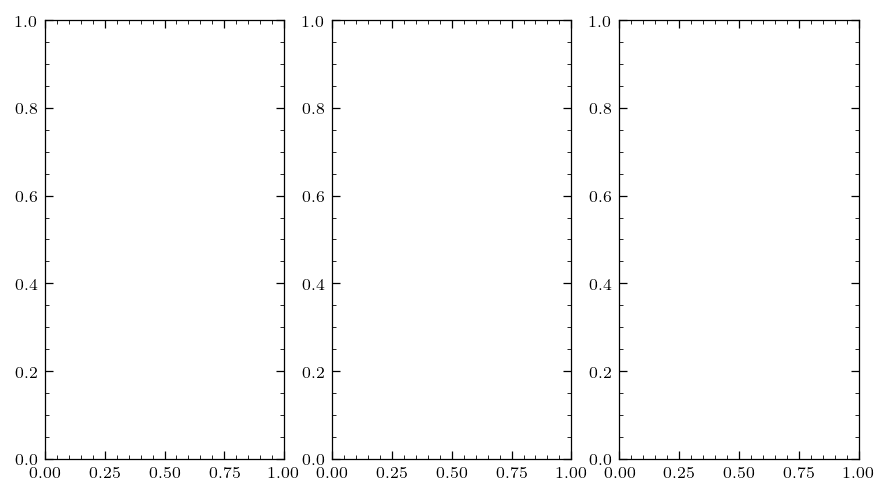

In [3]:
import time
from spectroxide import apply_style, C, DOUBLE_COL
from spectroxide.plot_params import SAVE_DPI, LW, LW_THIN, LW_AXIS, LEGEND_SIZE

apply_style()

# run_pde_photon default injection amplitude (delta_n_over_n=1e-7).
# Do NOT use the global dn_over_n here — cell 5 resets it to 1e-5 for Fig 2.
_DN_OVER_N = 1e-5

# --- Configuration ---
x_inj_list = [0.1, 1.0, 5.0]
z_inj_list = [1e4, 1e5, 5e5, 2e6]

# Redshifts in the intermediate mu-y regime (3e4 < z < 2e5) where
# the GF uses a smooth J_mu interpolation that is not well supported
# by physics.  Show PDE only for these; skip GF overlay.
_INTERMEDIATE_Z = {z for z in z_inj_list if 3e4 < z < 2e5}

colors_z = {
    1e4: C["blue"],
    1e5: C["orange"],
    5e5: C["teal"],
    2e6: C["red"],
}
labels_z = {
    1e4: r'$z_h = 10^4$',
    1e5: r'$z_h = 10^5$',
    5e5: r'$z_h = 5\times10^5$',
    2e6: r'$z_h = 2\times 10^6$',
}

fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL, 3.8),
                         sharex='col')
t0 = time.time()

x_obs = np.logspace(np.log10(1e-2), np.log10(20), 500)

for col, x_i in enumerate(x_inj_list):
    ax_top = axes[col]
    sx = default_sigma_x(x_i)
    n_pts = 4000

    for z_h in z_inj_list:
        color = colors_z[z_h]

        # --- PDE ---
        key = (x_i, z_h, n_pts)
        if key not in pde_spectra:
            print(f'  Running PDE: x_i={x_i}, z_h={z_h:.0e}, n={n_pts} ...', end='', flush=True)
            pde_spectra[key] = run_pde_photon(x_i, z_h, n_points=n_pts, timeout=1000)
            print(' done')
        x_pde, dn_pde, mu_pde, y_pde = pde_spectra[key]

        # Strip G_bb (temperature shift) from PDE before plotting
        pde_norm = dn_pde / _DN_OVER_N
        pde_nc, _ = strip_gbb(x_pde, pde_norm)
        _, di_pde_jy = delta_n_to_delta_I(x_pde, pde_nc)
        di_pde_mjy = di_pde_jy / 1e6

        m = (x_pde >= 1e-2) & (x_pde <= 20)
        ax_top.plot(x_pde[m], di_pde_mjy[m], '-', color=color, lw=LW,
                    label=labels_z[z_h] if col == 0 else None)

        # --- GF (skip intermediate regime where neither pure mu nor pure y) ---
        if z_h not in _INTERMEDIATE_Z:
            gf_raw = greens_function_photon(x_obs, x_i, z_h, sigma_x=sx, number_conserving=False)
            gf_nc, _ = strip_gbb(x_obs, gf_raw)
            _, di_gf_jy = delta_n_to_delta_I(x_obs, gf_nc)
            di_gf_mjy = di_gf_jy / 1e6

            ax_top.plot(x_obs, di_gf_mjy, '--', color=color, alpha=1)

    # Top panel formatting
    ax_top.set_xscale('log')
    ax_top.set_xlabel(r"$x$")
    ax_top.set_xlim(1e-2, 20)
    ax_top.set_ylim(-500, 850)
    ax_top.set_title(rf'$x_{{\mathrm{{inj}}}} = {x_i}$')
    ax_top.axhline(0, color='k', lw=LW_AXIS, ls=':')

    if col == 0:
        ax_top.set_ylabel(r'$\Delta I$ [MJy/sr per $\Delta N/N$]')

# Legend in first panel
axes[0].legend(loc='upper right', fontsize=LEGEND_SIZE)
axes[2].text(0.4, 0.95, 'solid: PDE\ndashed: GF',
                transform=axes[2].transAxes, fontsize=LEGEND_SIZE,
                ha='right', va='top')

plt.tight_layout()
fig.subplots_adjust(hspace=0.08)
print(f'Total: {time.time()-t0:.0f}s')
plt.savefig(FIG_DIR / 'photon_injection_spectra.pdf', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()